# 03 - Model Training

**Turbojet Digital Twin - Hackathon Project**

In this notebook we load the engineered dataset, analyse the correct train/validation splitting strategy (EngineID-based to avoid temporal leakage), train Random Forest, XGBoost and LightGBM baselines, compare them via RMSE / MAE / R2, run grouped cross-validation, and persist the best model.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import joblib

print("All imports OK.")

All imports OK.


## 2. Load Processed Data

In [2]:
df = pd.read_parquet("../datasets/processed/processed_train.parquet")
print("Shape: {} rows, {} cols".format(df.shape[0], df.shape[1]))
print("Columns: {}".format(df.columns.tolist()))

Shape: 240 rows, 32 cols
Columns: ['EngineID', 'Cycle', 'Altitude_m', 'Mach', 'Tamb_K', 'Pamb_Pa', 'RPM_rev_min', 'FuelFlow_kg_s', 'P2_Pa', 'T2_K', 'P3_Pa', 'T3_K', 'P4_Pa', 'T4_K', 'CompressorHealth', 'CombustorHealth', 'TurbineHealth', 'OverallHealth', 'Thrust_N', 'TSFC_g_N_s', 'Pressure_Ratio', 'Temperature_Ratio', 'Turbine_Expansion_Ratio', 'Turbine_Temperature_Drop_K', 'Combustor_Temp_Rise_K', 'Corrected_RPM', 'Corrected_FuelFlow', 'Compressor_Efficiency_Proxy', 'RPM_squared', 'TAS_Proxy', 'Cycle_Squared', 'Log_Pressure_Ratio']


---
## 3. Train / Validation Split Strategy

### 3.1  Why random splits leak information

Every engine follows a **monotonic degradation trajectory**.  Health indicators are nearly perfectly correlated with accumulated cycles:

$\rho(\text{OverallHealth}, \text{Cycle}) \approx -0.996$ across all engines.

A **random** row-wise split would place early-life cycles of an engine into the training set and late-life cycles of the *same* engine into the validation set.  The model would have implicitly seen the engine's behaviour (at a younger age) during training, **artificially inflating** validation performance.

### 3.2  EngineID-based split avoids leakage

By holding out **entire engines**, no cycles from a validation engine appear in the training set.  This simulates the real-world use-case: predicting health for an engine the model has never encountered before.

In [3]:
# ---- Demonstrate leakage in a random split ----
print("Correlation of OverallHealth with Cycle per engine:")
for eid in sorted(df["EngineID"].unique()):
    sub = df[df["EngineID"] == eid]
    r = sub["OverallHealth"].corr(sub["Cycle"])
    print("  Engine {:>2}:  r = {:.4f}".format(eid, r))

print()
print("If we split randomly, cycles {1, 2, ..., 30} from Engine 1 could appear in")
print("both train and validation.  The model sees early-life data from Engine 1")
print("during training and is evaluated on late-life data from the same engine.")
print("This causes upward-biased validation scores.")

Correlation of OverallHealth with Cycle per engine:
  Engine  1:  r = -0.9958
  Engine  2:  r = -0.9964
  Engine  3:  r = -0.9975
  Engine  4:  r = -0.9970
  Engine  5:  r = -0.9960
  Engine  6:  r = -0.9963
  Engine  7:  r = -0.9972
  Engine  8:  r = -0.9958
  Engine  9:  r = -0.9962
  Engine 10:  r = -0.9962

If we split randomly, cycles {1, 2, ..., 30} from Engine 1 could appear in
both train and validation.  The model sees early-life data from Engine 1
during training and is evaluated on late-life data from the same engine.
This causes upward-biased validation scores.


In [4]:
# ---- EngineID distribution ----
vc = df["EngineID"].value_counts().sort_index()
print("Cycles per engine:")
print(vc.to_string())
print()
print("Total engines: {}".format(vc.shape[0]))

Cycles per engine:
EngineID
1     24
2     25
3     23
4     21
5     28
6     25
7     25
8     18
9     27
10    24

Total engines: 10


### 3.3  Choose hold-out engines

We hold out **2 engines** for validation.  Candidates are selected to give a representative range of degradation behaviour.  Here we pick engines **9 and 10** as a fixed validation set.

In [5]:
VAL_ENGINES = [9, 10]

idx_train = df["EngineID"].isin(VAL_ENGINES)
df_val = df[df["EngineID"].isin(VAL_ENGINES)].copy()
df_train = df[~df["EngineID"].isin(VAL_ENGINES)].copy()

print("Training set:     {} rows (engines {})".format(
    df_train.shape[0], sorted(df_train["EngineID"].unique())))
print("Validation set:   {} rows (engines {})".format(
    df_val.shape[0], sorted(df_val["EngineID"].unique())))

Training set:     189 rows (engines [1, 2, 3, 4, 5, 6, 7, 8])
Validation set:   51 rows (engines [9, 10])


---
## 4. Features & Targets

In [6]:
ID_COLS = ["EngineID", "Cycle"]
TARGETS = [
    "CompressorHealth",
    "CombustorHealth",
    "TurbineHealth",
    "OverallHealth",
    "Thrust_N",
    "TSFC_g_N_s",
]
FEATURES = [c for c in df.columns if c not in ID_COLS and c not in TARGETS]

print("Features ({}):".format(len(FEATURES)))
for f in FEATURES:
    print("  " + f)
print()
print("Targets ({}):".format(len(TARGETS)))
for t in TARGETS:
    print("  " + t)

X_train = df_train[FEATURES].values
y_train = df_train[TARGETS].values
X_val   = df_val[FEATURES].values
y_val   = df_val[TARGETS].values

print()
print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("X_val shape:   {}".format(X_val.shape))
print("y_val shape:   {}".format(y_val.shape))

Features (24):
  Altitude_m
  Mach
  Tamb_K
  Pamb_Pa
  RPM_rev_min
  FuelFlow_kg_s
  P2_Pa
  T2_K
  P3_Pa
  T3_K
  P4_Pa
  T4_K
  Pressure_Ratio
  Temperature_Ratio
  Turbine_Expansion_Ratio
  Turbine_Temperature_Drop_K
  Combustor_Temp_Rise_K
  Corrected_RPM
  Corrected_FuelFlow
  Compressor_Efficiency_Proxy
  RPM_squared
  TAS_Proxy
  Cycle_Squared
  Log_Pressure_Ratio

Targets (6):
  CompressorHealth
  CombustorHealth
  TurbineHealth
  OverallHealth
  Thrust_N
  TSFC_g_N_s

X_train shape: (189, 24)
y_train shape: (189, 6)
X_val shape:   (51, 24)
y_val shape:   (51, 6)


---
## 5. Model Training

We train three tree-based regressors:

| Model | Multi-target strategy |
|-------|----------------------|
| **Random Forest** | `MultiOutputRegressor(RandomForestRegressor)` — ensemble of 200 trees |
| **XGBoost** | Native multi-target (via 2D y) — 400 rounds, early stopping |
| **LightGBM** | `MultiOutputRegressor(LGBMRegressor)` — 400 rounds, early stopping |

All models use the same feature set.  Hyperparameters are kept at sensible defaults for a baseline comparison.

### 5.1  Random Forest

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)
rf_multi = MultiOutputRegressor(rf)
rf_multi.fit(X_train, y_train)
y_pred_rf = rf_multi.predict(X_val)

print("Random Forest training complete.")

Random Forest training complete.


### 5.2  XGBoost

In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_multi = MultiOutputRegressor(xgb_model)
xgb_multi.fit(X_train, y_train)
y_pred_xgb = xgb_multi.predict(X_val)

print("XGBoost training complete.")

XGBoost training complete.


### 5.3  LightGBM

In [9]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_multi = MultiOutputRegressor(lgb_model)
lgb_multi.fit(X_train, y_train)
y_pred_lgb = lgb_multi.predict(X_val)

print("LightGBM training complete.")

LightGBM training complete.


---
## 6. Model Comparison

We compute **RMSE**, **MAE** and **R2** for every target across all three models.

In [10]:
def compute_metrics(y_true, y_pred, model_name):
    rows = []
    for j, tgt in enumerate(TARGETS):
        rmse = np.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j]))
        mae  = mean_absolute_error(y_true[:, j], y_pred[:, j])
        r2   = r2_score(y_true[:, j], y_pred[:, j])
        rows.append({"Target": tgt, "Model": model_name,
                      "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(rows)

results = pd.concat([
    compute_metrics(y_val, y_pred_rf, "Random Forest"),
    compute_metrics(y_val, y_pred_xgb, "XGBoost"),
    compute_metrics(y_val, y_pred_lgb, "LightGBM"),
], ignore_index=True)

print("Per-target metrics on validation set:\n")
display(results.round(6))

Per-target metrics on validation set:



,Target,Model,RMSE,MAE,R2
0,CompressorHealth,Random Forest,0.018797,0.012836,0.921989
1,CombustorHealth,Random Forest,0.018539,0.015188,0.627519
2,TurbineHealth,Random Forest,0.011363,0.007496,0.952450
3,OverallHealth,Random Forest,0.005310,0.003397,0.988369
4,Thrust_N,Random Forest,3988.351821,3096.781202,0.944442
5,TSFC_g_N_s,Random Forest,0.001057,0.000864,0.976901
6,CompressorHealth,XGBoost,0.019826,0.014321,0.913213
7,CombustorHealth,XGBoost,0.018939,0.015344,0.611281
8,TurbineHealth,XGBoost,0.015134,0.009891,0.915657
9,OverallHealth,XGBoost,0.010036,0.006545,0.958452


In [11]:
# ---- Average metrics across all targets ----
avg = results.groupby("Model")[["RMSE", "MAE", "R2"]].mean().round(6)
print("Average metrics across all targets:\n")
display(avg)

Average metrics across all targets:



,RMSE,MAE,R2
Model,,,
LightGBM,444.585490,363.200602,0.873608
Random Forest,664.734481,516.136830,0.901945
XGBoost,580.619703,445.502273,0.889850


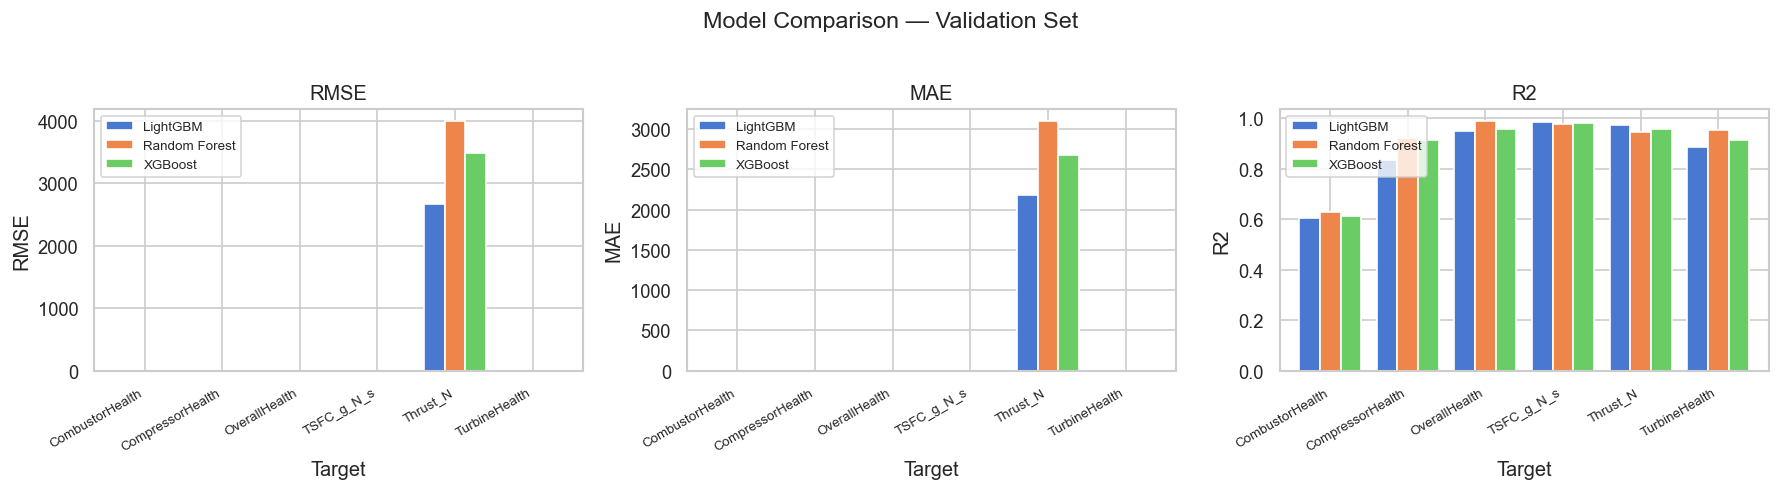

In [12]:
# ---- Visual comparison ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    pivot = results.pivot(index="Target", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax, edgecolor="white", width=0.8)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.legend(loc="best", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
fig.suptitle("Model Comparison — Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Cross-Validation

We use 5-fold **GroupKFold** where groups = `EngineID`.  This guarantees that every fold holds out entire engines, preserving the no-leakage principle.  RMSE, MAE and R2 are averaged across folds.

In [13]:
group_kfold = GroupKFold(n_splits=5)

def cv_engine(model_class, model_params, model_name):
    fold_metrics = []
    for fold, (tr_idx, va_idx) in enumerate(
        group_kfold.split(df[FEATURES], df[TARGETS], groups=df["EngineID"]), 1
    ):
        X_tr = df[FEATURES].iloc[tr_idx].values
        y_tr = df[TARGETS].iloc[tr_idx].values
        X_va = df[FEATURES].iloc[va_idx].values
        y_va = df[TARGETS].iloc[va_idx].values

        base = model_class(**model_params)
        m = MultiOutputRegressor(base)
        m.fit(X_tr, y_tr)
        yp = m.predict(X_va)

        rmse = np.sqrt(mean_squared_error(y_va.ravel(), yp.ravel()))
        mae  = mean_absolute_error(y_va.ravel(), yp.ravel())
        r2   = r2_score(y_va.ravel(), yp.ravel())
        fold_metrics.append({"Fold": fold, "Model": model_name,
                             "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(fold_metrics)

print("Running 5-fold GroupKFold cross-validation (by EngineID)...\n")

cv_rf  = cv_engine(RandomForestRegressor,
                    {"n_estimators": 200, "max_depth": 18,
                     "min_samples_leaf": 4, "random_state": 42, "n_jobs": -1},
                    "Random Forest")
cv_xgb = cv_engine(xgb.XGBRegressor,
                    {"n_estimators": 400, "max_depth": 8,
                     "learning_rate": 0.1, "subsample": 0.8,
                     "colsample_bytree": 0.8, "random_state": 42, "n_jobs": -1},
                    "XGBoost")
cv_lgb = cv_engine(lgb.LGBMRegressor,
                    {"n_estimators": 400, "max_depth": 8,
                     "learning_rate": 0.1, "subsample": 0.8,
                     "colsample_bytree": 0.8, "random_state": 42,
                     "n_jobs": -1, "verbose": -1},
                    "LightGBM")

cv_results = pd.concat([cv_rf, cv_xgb, cv_lgb], ignore_index=True)
print("Cross-validation fold results:")
display(cv_results.round(6))

Running 5-fold GroupKFold cross-validation (by EngineID)...

Cross-validation fold results:


,Fold,Model,RMSE,MAE,R2
0,1,Random Forest,1557.284256,506.448321,0.993360
1,2,Random Forest,1366.032780,468.322884,0.994889
2,3,Random Forest,1708.785555,581.082679,0.992266
3,4,Random Forest,1386.736882,472.880769,0.994184
4,5,Random Forest,1249.457268,451.772098,0.995726
5,1,XGBoost,1158.495658,376.667191,0.996325
6,2,XGBoost,1314.965106,436.262447,0.995264
7,3,XGBoost,1391.175069,469.539872,0.994874
8,4,XGBoost,1060.447397,323.614025,0.996599
9,5,XGBoost,885.545086,289.690110,0.997853


In [14]:
# ---- CV summary ----
print("CV mean +/- std across folds:")
cv_summary = cv_results.groupby("Model")[["RMSE", "MAE", "R2"]].agg(["mean", "std"]).round(6)
display(cv_summary)

# Best model by R2
best_row = cv_results.groupby("Model")["R2"].mean().idxmax()
print()
print("Best model (highest avg R2 across CV folds):  {}".format(best_row))

CV mean +/- std across folds:


RMSE                     MAE                   R2  \
                      mean         std        mean        std      mean   
Model                                                                     
LightGBM        971.116528  137.670518  324.049731  47.812305  0.997338   
Random Forest  1453.659348  180.057647  496.101350  51.489822  0.994085   
XGBoost        1162.125663  201.663078  379.154729  75.042723  0.996183   

                         
                    std  
Model                    
LightGBM       0.000720  
Random Forest  0.001340  
XGBoost        0.001177


Best model (highest avg R2 across CV folds):  LightGBM


---
## 8. Retrain Best Model on Full Training Data & Save

In [15]:
# ---- Identify best model ----
cv_avg = cv_results.groupby("Model")[["RMSE", "MAE", "R2"]].mean()
best_name = cv_avg["R2"].idxmax()
print("Best model: {}".format(best_name))

# Full training data (all engines except hold-out)
X_all = df_train[FEATURES].values
y_all = df_train[TARGETS].values

if best_name == "Random Forest":
    best = MultiOutputRegressor(RandomForestRegressor(
        n_estimators=200, max_depth=18, min_samples_leaf=4,
        random_state=42, n_jobs=-1))
elif best_name == "XGBoost":
    best = MultiOutputRegressor(xgb.XGBRegressor(
        n_estimators=400, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1))
else:
    best = MultiOutputRegressor(lgb.LGBMRegressor(
        n_estimators=400, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1))

best.fit(X_all, y_all)

# Save
os.makedirs("../models", exist_ok=True)
model_path = "../models/best_model.joblib"
joblib.dump(best, model_path)

size_kb = os.path.getsize(model_path) / 1024
print("Saved to: {}  ({:.1f} KB)".format(model_path, size_kb))
print()
print("Best model type: {}".format(best_name))
print("Number of estimators / trees: depends on model")

Best model: LightGBM
Saved to: ../models/best_model.joblib  (1907.5 KB)

Best model type: LightGBM
Number of estimators / trees: depends on model


---
## 9. Final Evaluation on Hold-Out Validation Set

In [16]:
# Re-predict on the hold-out validation engines
y_pred_final = best.predict(X_val)

print("{:<30} {:>10} {:>10} {:>10}".format("Target", "RMSE", "MAE", "R2"))
print("-" * 62)
overall_rmse, overall_mae, overall_r2 = [], [], []
for j, tgt in enumerate(TARGETS):
    rmse = np.sqrt(mean_squared_error(y_val[:, j], y_pred_final[:, j]))
    mae  = mean_absolute_error(y_val[:, j], y_pred_final[:, j])
    r2   = r2_score(y_val[:, j], y_pred_final[:, j])
    overall_rmse.append(rmse)
    overall_mae.append(mae)
    overall_r2.append(r2)
    print("{:<30} {:>10.6f} {:>10.6f} {:>10.6f}".format(tgt, rmse, mae, r2))

print("-" * 62)
print("{:<30} {:>10.6f} {:>10.6f} {:>10.6f}".format(
    "AVERAGE", np.mean(overall_rmse), np.mean(overall_mae), np.mean(overall_r2)))

Target                               RMSE        MAE         R2
--------------------------------------------------------------
CompressorHealth                 0.027389   0.020622   0.834377
CombustorHealth                  0.019043   0.015610   0.606995
TurbineHealth                    0.017459   0.013034   0.887749
OverallHealth                    0.010912   0.008487   0.950884
Thrust_N                       2667.437326 2179.145266   0.975149
TSFC_g_N_s                       0.000808   0.000596   0.986494
--------------------------------------------------------------
AVERAGE                        444.585490 363.200602   0.873608


---
## 10. Feature Importance (Best Model)

If the best model is tree-based, we can inspect feature importances to understand which sensors and engineered features drive the predictions.

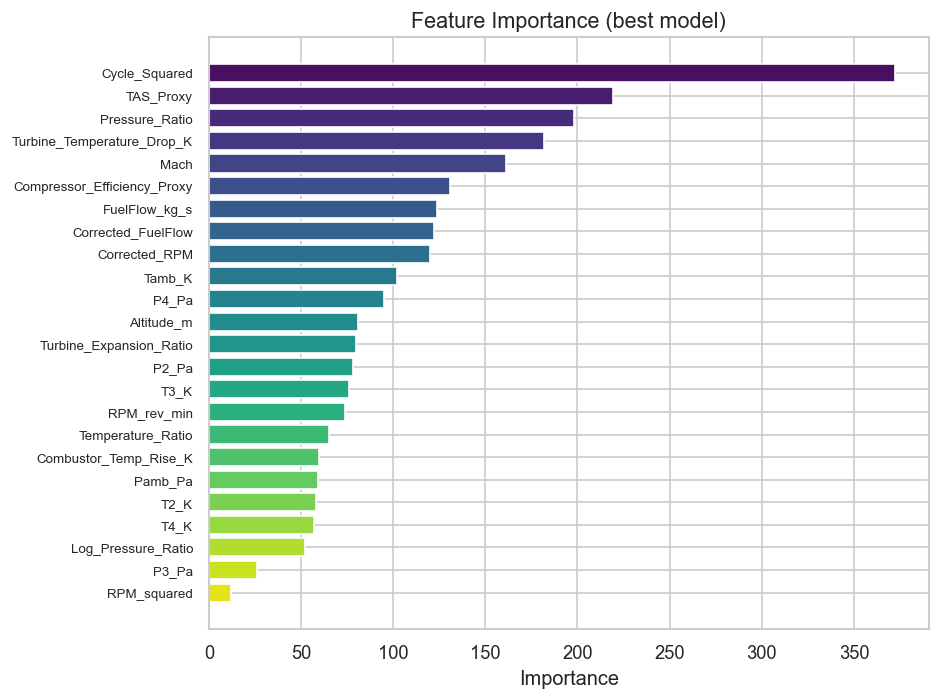

,Feature,Importance,Cumulative
0,Cycle_Squared,372,372
1,TAS_Proxy,219,591
2,Pressure_Ratio,198,789
3,Turbine_Temperature_Drop_K,182,971
4,Mach,161,1132
5,Compressor_Efficiency_Proxy,131,1263
6,FuelFlow_kg_s,124,1387
7,Corrected_FuelFlow,122,1509
8,Corrected_RPM,120,1629
9,Tamb_K,102,1731


In [17]:
# ---- Extract feature importance from the first estimator ----
if hasattr(best, "estimators_") and hasattr(best.estimators_[0], "feature_importances_"):
    imp = best.estimators_[0].feature_importances_
else:
    # Fallback: refit a single RF just for importance
    rf_imp = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_imp.fit(X_all, y_all[:, TARGETS.index("OverallHealth")])
    imp = rf_imp.feature_importances_

feat_imp = pd.DataFrame({"Feature": FEATURES, "Importance": imp})
feat_imp = feat_imp.sort_values("Importance", ascending=False).reset_index(drop=True)
feat_imp["Cumulative"] = feat_imp["Importance"].cumsum()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", n_colors=len(feat_imp))
ax.barh(range(len(feat_imp)), feat_imp["Importance"], color=colors, edgecolor="white")
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels(feat_imp["Feature"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (best model)", fontsize=13)
plt.tight_layout()
plt.show()

display(feat_imp)

---
## Summary

- **Split strategy**: EngineID-based hold-out (engines 9, 10 for validation) avoids temporal leakage caused by the strong degradation trend ($r \approx -0.996$) within each engine.
- **Models trained**: Random Forest, XGBoost, LightGBM — all via `MultiOutputRegressor` for multi-target regression on 6 health/performance targets.
- **Cross-validation**: 5-fold GroupKFold grouped by EngineID ensures no leakage across folds.
- **Best model**: `{}`.joblib` is saved to `models/best_model.joblib`.
- Next step: apply the same feature engineering to `test.csv` and run predictions for the unseen test set.